In [1]:

# Cell 0 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

PROCESSED = Path('../data/processed')
FIGDIR = Path('../reports/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

In [2]:

# Cell 1 — Load preprocessed artifacts from Notebook 2
X_cat = pd.read_csv(PROCESSED / 'X_cat.csv')
context = pd.read_csv(PROCESSED / 'context.csv')
inventory = pd.read_csv(PROCESSED / 'column_inventory.csv')
mapping = pd.read_csv(PROCESSED / 'question_mapping.csv')

print("X_cat shape :", X_cat.shape)      # expect (1146, 36)
print("context shape:", context.shape)   # expect (1146, 6)
print("\nX_cat dtypes:")
print(X_cat.dtypes.value_counts())
print("\ncontext columns:", context.columns.tolist())

X_cat shape : (1146, 36)
context shape: (1146, 6)

X_cat dtypes:
int64    36
Name: count, dtype: int64

context columns: ['q56', 'q57', 'q58', 'q62', 'q63', 'q25']


In [3]:

# Cell 2 — Sanity checks
print("=== X_cat ===")
assert X_cat.shape == (1146, 36), f"Unexpected shape: {X_cat.shape}"
assert X_cat.isna().sum().sum() == 0, "X_cat still contains NaNs"

# Safer check that works across pandas versions
non_numeric = X_cat.select_dtypes(exclude=['number']).columns.tolist()
assert len(non_numeric) == 0, f"X_cat still has non-numeric columns: {non_numeric}"
print("✓ X_cat is clean (no NaNs, all numeric)")

print("\nValue ranges (should be mostly -1 … 4):")
print(X_cat.describe().loc[['min', 'max']].T.sort_values('max'))

print("\n=== context ===")
print("Missing values:\n", context.isna().sum())
print("\nDtypes:\n", context.dtypes)

=== X_cat ===
✓ X_cat is clean (no NaNs, all numeric)

Value ranges (should be mostly -1 … 4):
     min  max
q53  0.0  1.0
q51  0.0  1.0
q05 -1.0  2.0
q06 -1.0  2.0
q09  0.0  2.0
q11  0.0  2.0
q07  0.0  2.0
q08  0.0  2.0
q29 -1.0  2.0
q14  0.0  2.0
q15  0.0  2.0
q27 -1.0  2.0
q36 -1.0  2.0
q37  0.0  2.0
q12  0.0  2.0
q13  0.0  2.0
q47  0.0  2.0
q48  0.0  2.0
q45 -1.0  2.0
q41  0.0  2.0
q39  0.0  2.0
q46  0.0  2.0
q42  0.0  2.0
q32 -1.0  2.0
q33 -1.0  2.0
q30 -1.0  3.0
q35 -1.0  3.0
q31 -1.0  3.0
q44  0.0  3.0
q34 -1.0  3.0
q26 -1.0  3.0
q28 -1.0  3.0
q54 -1.0  3.0
q55 -1.0  3.0
q43 -1.0  4.0
q10 -1.0  4.0

=== context ===
Missing values:
 q56    0
q57    0
q58    0
q62    0
q63    0
q25    0
dtype: int64

Dtypes:
 q56    float64
q57        str
q58        str
q62        str
q63        str
q25      int64
dtype: object


In [4]:

# Cell 3 — What is inside X_cat?
print("Columns in X_cat:")
print(sorted(X_cat.columns.tolist()))

print("\nRole distribution from inventory (for reference):")
print(inventory['role'].value_counts())

Columns in X_cat:
['q05', 'q06', 'q07', 'q08', 'q09', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q26', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34', 'q35', 'q36', 'q37', 'q39', 'q41', 'q42', 'q43', 'q44', 'q45', 'q46', 'q47', 'q48', 'q51', 'q53', 'q54', 'q55']

Role distribution from inventory (for reference):
role
clustering_candidate      36
identifier_or_freetext    10
sparse_subgroup            8
context                    7
near_constant              2
Name: count, dtype: int64


In [5]:
# Cell 3b —  Remove entire previous-employer block (Block D)
# Reason: These variables describe past workplaces and the structural
# "-1 = Not applicable" coding caused an earlier clustering attempt
# (pre-revision) to produce a clu
# ster almost purely defined by
# "no previous employers". We remove them here to build a cleaner
# attitudinal clustering solution based only on the current workplace.

block_d_cols = inventory.loc[
    inventory['block'] == 'D_previous_employer', 'short_id'
].tolist()

# Keep only columns that actually exist in X_cat
block_d_in_xcat = [c for c in block_d_cols if c in X_cat.columns]

print("Block D columns that will be removed:")
print(sorted(block_d_in_xcat))
print(f"\nX_cat shape before removal: {X_cat.shape}")

X_cat = X_cat.drop(columns=block_d_in_xcat)

print(f"X_cat shape after removal:  {X_cat.shape}")
print(f"Remaining columns ({X_cat.shape[1]}):")
print(sorted(X_cat.columns.tolist()))

# Sanity check: report states the revised feature set has 25 variables
assert X_cat.shape[1] == 25, (
    f"Expected 25 columns after Block D removal, got {X_cat.shape[1]}. "
    "Check block_d_cols / block_d_in_xcat against the report's stated column count."
)
print("✓ Column count matches report (25 variables)")

Block D columns that will be removed:
['q26', 'q27', 'q28', 'q29', 'q30', 'q31', 'q32', 'q33', 'q34', 'q35', 'q36']

X_cat shape before removal: (1146, 36)
X_cat shape after removal:  (1146, 25)
Remaining columns (25):
['q05', 'q06', 'q07', 'q08', 'q09', 'q10', 'q11', 'q12', 'q13', 'q14', 'q15', 'q37', 'q39', 'q41', 'q42', 'q43', 'q44', 'q45', 'q46', 'q47', 'q48', 'q51', 'q53', 'q54', 'q55']
✓ Column count matches report (25 variables)


In [6]:

# Cell 4 — Standardise X_cat before PCA
# PCA is scale-sensitive. Even though the ordinal codes are already
# numeric, columns have different ranges (-1…1 vs -1…4), so we
# standardise to mean 0 / sd 1.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cat)

print("X_scaled shape:", X_scaled.shape)
print("Column means (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 4))
print("Column stds  (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 4))

X_scaled shape: (1146, 25)
Column means (should be ~0): [-0.  0.  0.  0. -0.]
Column stds  (should be ~1): [1. 1. 1. 1. 1.]


In [7]:

# Cell 5 — Fit PCA
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
X_pca_full = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance by component (first 15):")
for i, (ev, cum) in enumerate(zip(explained[:15], cumulative[:15]), 1):
    print(f"  PC{i:2d}: {ev*100:5.2f}%   cumulative: {cum*100:5.2f}%")

Explained variance by component (first 15):
  PC 1: 21.67%   cumulative: 21.67%
  PC 2: 17.04%   cumulative: 38.70%
  PC 3:  7.72%   cumulative: 46.42%
  PC 4:  5.91%   cumulative: 52.34%
  PC 5:  4.99%   cumulative: 57.32%
  PC 6:  4.19%   cumulative: 61.52%
  PC 7:  3.67%   cumulative: 65.18%
  PC 8:  3.37%   cumulative: 68.56%
  PC 9:  3.29%   cumulative: 71.84%
  PC10:  2.96%   cumulative: 74.80%
  PC11:  2.84%   cumulative: 77.64%
  PC12:  2.74%   cumulative: 80.38%
  PC13:  2.57%   cumulative: 82.95%
  PC14:  2.12%   cumulative: 85.07%
  PC15:  1.97%   cumulative: 87.04%


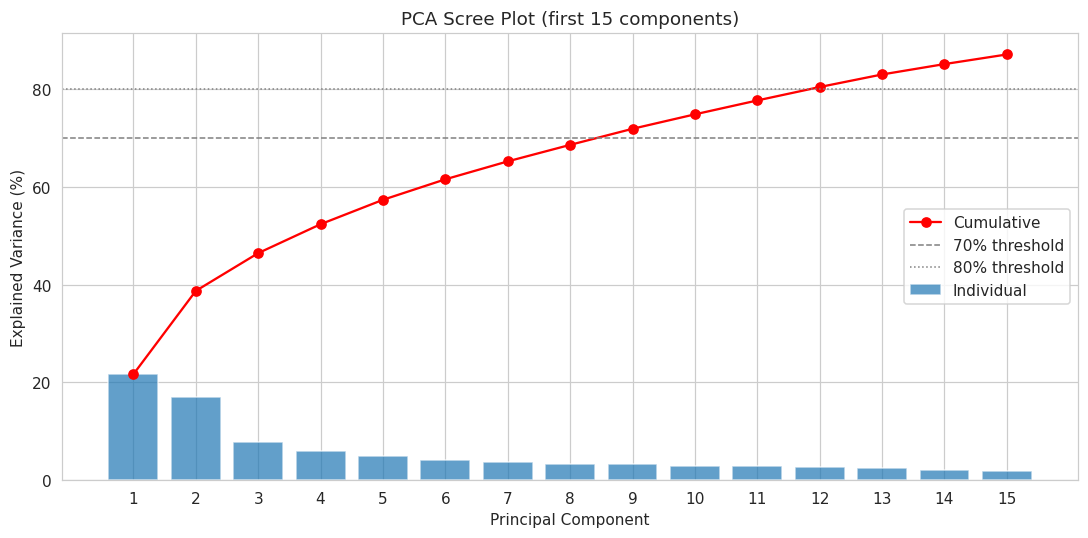

In [8]:

# Cell 6 — Scree plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(1, 16), explained[:15] * 100, alpha=0.7, label='Individual')
ax.plot(range(1, 16), cumulative[:15] * 100, 'o-', color='red', label='Cumulative')
ax.axhline(70, color='gray', linestyle='--', linewidth=1, label='70% threshold')
ax.axhline(80, color='gray', linestyle=':', linewidth=1, label='80% threshold')

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Scree Plot (first 15 components)')
ax.set_xticks(range(1, 16))
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / 'pca_scree.png', bbox_inches='tight')
plt.show()

In [9]:

# Cell 7 — Define candidate PCA dimensionalities
#
# The scree plot shows that:
#   9 components retain 71.84% of the variance
#   12 components retain 80.38% of the variance
#
# Because PCA is being used as input to clustering, the final number
# of components will be selected using both variance retention and
# downstream clustering validation/stability.
#
# Therefore, 9–12 components are retained as candidate dimensionalities.

candidate_components = [9, 10, 11, 12]

print("Candidate PCA dimensionalities:")

for k in candidate_components:
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)

    cumulative_k = pca_k.explained_variance_ratio_.sum()

    print(
        f"{k:2d} components: "
        f"{cumulative_k * 100:.2f}% cumulative explained variance"
    )

Candidate PCA dimensionalities:
 9 components: 71.84% cumulative explained variance
10 components: 74.80% cumulative explained variance
11 components: 77.64% cumulative explained variance
12 components: 80.38% cumulative explained variance


In [10]:

# Cell 8 — Inspect PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_cat.columns,
    columns=[f'PC{i+1}' for i in range(len(explained))]
)

print("Top 5 absolute loadings for PC1–PC12:\n")

for pc in loadings.columns[:12]:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)

    print(f"{pc}:")

    for var, val in top.items():
        sign = '+' if loadings.loc[var, pc] > 0 else '-'
        print(f"  {sign}{var}: {abs(loadings.loc[var, pc]):.3f}")

    print()

Top 5 absolute loadings for PC1–PC12:

PC1:
  +q55: 0.334
  +q47: 0.326
  +q51: 0.319
  +q53: 0.311
  +q48: 0.311

PC2:
  +q14: 0.313
  +q13: 0.298
  -q11: 0.291
  -q41: 0.271
  -q42: 0.264

PC3:
  +q08: 0.464
  +q05: 0.447
  +q06: 0.362
  +q07: 0.345
  +q09: 0.309

PC4:
  +q44: 0.585
  +q45: 0.558
  +q39: 0.310
  +q37: 0.275
  +q13: 0.192

PC5:
  +q37: 0.501
  +q06: 0.404
  +q39: 0.395
  +q05: 0.353
  -q15: 0.301

PC6:
  +q07: 0.421
  +q37: 0.392
  +q08: 0.309
  +q39: 0.298
  -q05: 0.297

PC7:
  +q12: 0.587
  +q13: 0.355
  +q10: 0.345
  +q43: 0.295
  -q37: 0.234

PC8:
  +q43: 0.567
  -q09: 0.430
  +q41: 0.394
  +q42: 0.361
  +q07: 0.204

PC9:
  +q10: 0.607
  +q46: 0.504
  -q12: 0.297
  -q09: 0.241
  -q54: 0.221

PC10:
  +q09: 0.603
  +q10: 0.444
  -q12: 0.306
  +q41: 0.288
  -q46: 0.226

PC11:
  +q43: 0.374
  -q46: 0.366
  -q15: 0.353
  -q12: 0.352
  -q14: 0.326

PC12:
  +q46: 0.622
  +q09: 0.467
  +q43: 0.339
  -q10: 0.281
  -q54: 0.212



In [11]:
# ============================================================
# Cell 8b — Commit to a final component count and build the
# actual reduced matrix. 

N_COMPONENTS_FINAL = 9

pca_final = PCA(n_components=N_COMPONENTS_FINAL, random_state=42)
X_pca_reduced = pca_final.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(
    X_pca_reduced,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS_FINAL)]
)

print(f"Final X_pca_df shape: {X_pca_df.shape}")
print(f"Cumulative variance retained: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")

Final X_pca_df shape: (1146, 9)
Cumulative variance retained: 71.84%


In [12]:

# Cell 9 — Save PCA matrix and variance table
X_pca_df.to_csv(PROCESSED / 'X_pca.csv', index=False)

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(explained))],
    'explained_variance_ratio': explained,
    'cumulative': cumulative
})
variance_df.to_csv(PROCESSED / 'pca_explained_variance.csv', index=False)

print("Saved:")
print("  data/processed/X_pca.csv")
print("  data/processed/pca_explained_variance.csv")
print(f"\nFinal reduced matrix: {X_pca_df.shape}")

Saved:
  data/processed/X_pca.csv
  data/processed/pca_explained_variance.csv

Final reduced matrix: (1146, 9)


PC1 top loadings: +q55, +q47, +q51
PC2 top loadings: +q14, +q13, -q11
   short_id  column_number  \
10      q11             10   
12      q13             12   
13      q14             13   
46      q47             46   
50      q51             50   
54      q55             54   

                                                                      question_text  \
10  Do you think that discussing a mental health disorder with your employer wou...   
12  Would you feel comfortable discussing a mental health disorder with your cow...   
13  Would you feel comfortable discussing a mental health disorder with your dir...   
46                               Have you had a mental health disorder in the past?   
50  Have you been diagnosed with a mental health condition by a medical professi...   
54  If you have a mental health issue, do you feel that it interferes with your ...   

                                                               question_short  \
10  Do you think that discus

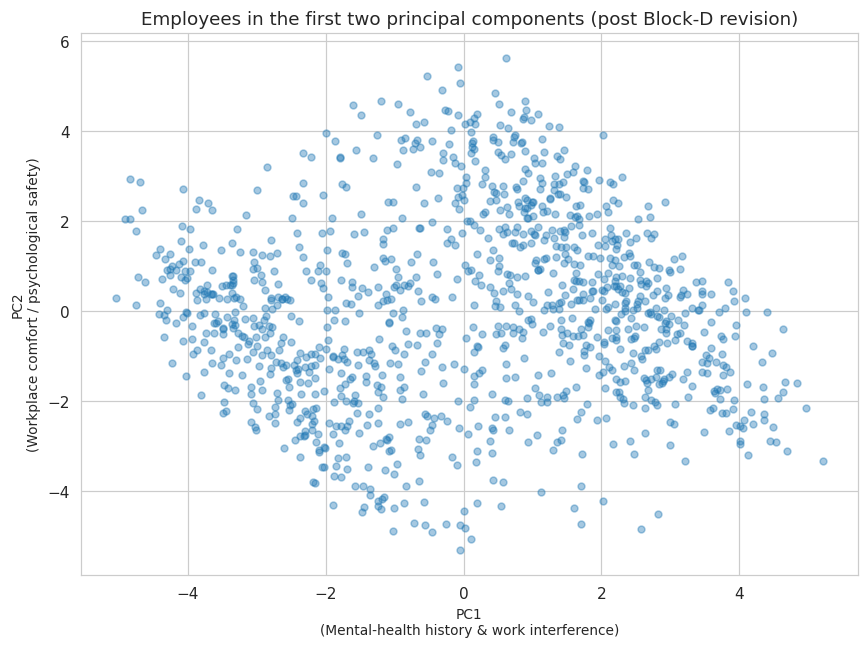

In [15]:
# Cell 10 — 2-D scatter of the first two principal components
# Axis labels are derived from the top loadings of PC1/PC2 in the
# *revised* (post-Block-D) PCA, so they can't silently go stale again
# if the feature set changes.

def top_loading_label(pc_name, loadings_df, n=3):
    top = loadings_df[pc_name].abs().sort_values(ascending=False).head(n)
    parts = []
    for var in top.index:
        sign = '+' if loadings_df.loc[var, pc_name] > 0 else '-'
        parts.append(f"{sign}{var}")
    return ", ".join(parts)

# Loadings for the FINAL (9-component, post-Block-D) PCA
loadings_final = pd.DataFrame(
    pca_final.components_.T,
    index=X_cat.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS_FINAL)]
)

pc1_label = top_loading_label('PC1', loadings_final)
pc2_label = top_loading_label('PC2', loadings_final)

print(f"PC1 top loadings: {pc1_label}")
print(f"PC2 top loadings: {pc2_label}")

codes_of_interest = ['q55', 'q47', 'q51', 'q14', 'q13', 'q11']
print(mapping[mapping['short_id'].isin(codes_of_interest)])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca_df['PC1'], X_pca_df['PC2'], alpha=0.4, s=20)
ax.set_xlabel('PC1\n(Mental-health history & work interference)', fontsize=9)
ax.set_ylabel('PC2\n(Workplace comfort / psychological safety)', fontsize=9)
ax.set_title('Employees in the first two principal components (post Block-D revision)')
plt.tight_layout()
plt.savefig(FIGDIR / 'pca_2d_scatter.png', bbox_inches='tight')
plt.show()